In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report, confusion_matrix, recall_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [4]:
df = pd.read_csv(r'Y:\course ML NTI\VSC\Project\healthcare-dataset-stroke-data.csv')
print("Shape:", df.shape)
df.head()

Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [5]:
df.nunique()

id                   5110
gender                  3
age                   104
hypertension            2
heart_disease           2
ever_married            2
work_type               5
Residence_type          2
avg_glucose_level    3979
bmi                   418
smoking_status          4
stroke                  2
dtype: int64

In [6]:
df.isna().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [7]:
cat_cols = df.select_dtypes(include=['object', 'string']).columns
for col in cat_cols:
    print(df[col].value_counts().to_string())
    print("=" * 25)

gender
Female    2994
Male      2115
Other        1
ever_married
Yes    3353
No     1757
work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Residence_type
Urban    2596
Rural    2514
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789


In [8]:
print(df['stroke'].value_counts())
print(df['stroke'].value_counts(normalize=True) * 100)

stroke
0    4861
1     249
Name: count, dtype: int64
stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


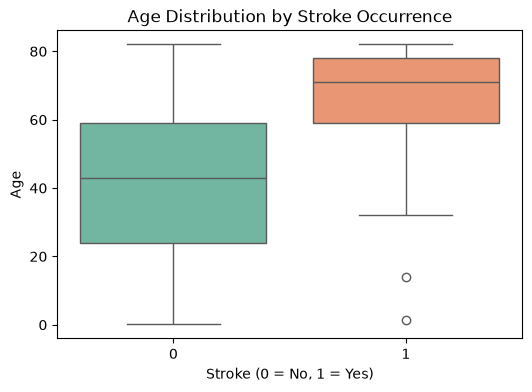

In [9]:
df = df.drop(columns=['id'])
df = df[df['gender'] != 'Other']

plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='stroke', y='age', hue='stroke', palette='Set2', legend=False)
plt.title('Age Distribution by Stroke Occurrence')
plt.xlabel('Stroke (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.show()

In [10]:
df_encoded = pd.get_dummies(df, drop_first=True)
X = df_encoded.drop(columns=['stroke'])
y = df_encoded['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

bmi_train_median = X_train['bmi'].median()
X_train['bmi'] = X_train['bmi'].fillna(bmi_train_median)
X_test['bmi'] = X_test['bmi'].fillna(bmi_train_median)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (4087, 15)
Test shape: (1022, 15)


# KNN Tuning

Optimal Settings: K = 3, Metric = manhattan, Best F1 = 0.1212


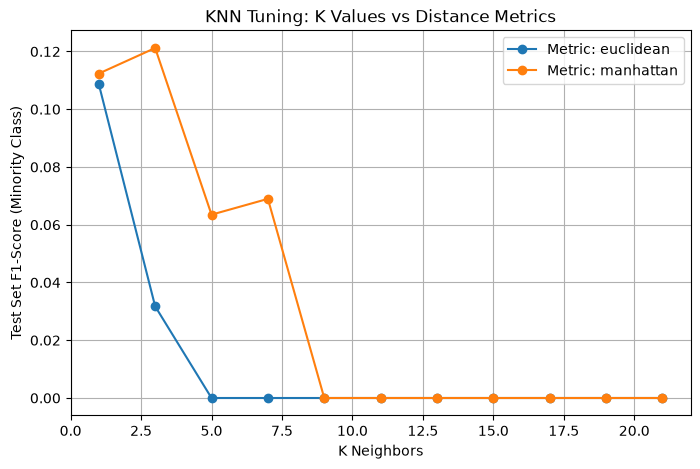

In [11]:
k_values = list(range(1, 22, 2))
metrics = ['euclidean', 'manhattan']

best_score = -1
best_k = None
best_metric = None

plt.figure(figsize=(8, 5))
for m in metrics:
    f1_scores = []
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, metric=m, weights='distance')
        knn.fit(X_train_scaled, y_train)
        preds = knn.predict(X_test_scaled)
        score = f1_score(y_test, preds, zero_division=0)
        f1_scores.append(score)

        if score > best_score:
            best_score = score
            best_k = k
            best_metric = m
    
    plt.plot(k_values, f1_scores, marker='o', label=f'Metric: {m}')
print(f"Optimal Settings: K = {best_k}, Metric = {best_metric}, Best F1 = {best_score:.4f}")
plt.xlabel('K Neighbors')
plt.ylabel('Test Set F1-Score (Minority Class)')
plt.title('KNN Tuning: K Values vs Distance Metrics')
plt.legend()
plt.grid(True)
plt.show()

# KNN (Threshold = 0.5) vs (Threshold = 0.15)

KNN with Threshold Tuning (0.15) Report
              precision    recall  f1-score   support

           0       0.96      0.88      0.92       972
           1       0.09      0.24      0.13        50

    accuracy                           0.85      1022
   macro avg       0.53      0.56      0.53      1022
weighted avg       0.92      0.85      0.88      1022



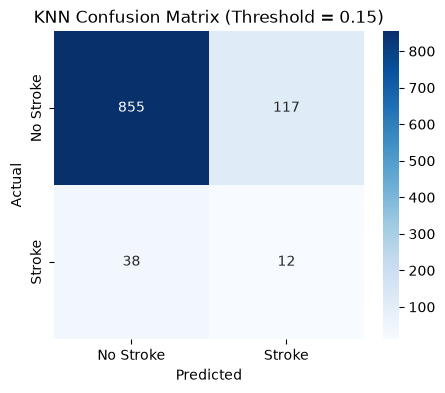

In [12]:
final_knn = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric, weights='distance')
final_knn.fit(X_train_scaled, y_train)

knn_baseline_preds = final_knn.predict(X_test_scaled)

knn_probs = final_knn.predict_proba(X_test_scaled)[:, 1]
threshold = 0.15
knn_tuned_preds = (knn_probs >= threshold).astype(int)

print("KNN with Threshold Tuning (0.15) Report")
print(classification_report(y_test, knn_tuned_preds))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, knn_tuned_preds), annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
plt.title('KNN Confusion Matrix (Threshold = 0.15)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Random Forest Classifier

Random Forest (Balanced Weights) Report
              precision    recall  f1-score   support

           0       0.97      0.90      0.93       972
           1       0.21      0.54      0.31        50

    accuracy                           0.88      1022
   macro avg       0.59      0.72      0.62      1022
weighted avg       0.94      0.88      0.90      1022



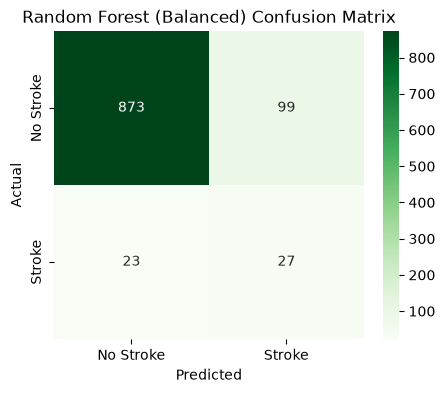

In [13]:
rf_model = RandomForestClassifier(
    n_estimators=150,
    class_weight='balanced',
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("Random Forest (Balanced Weights) Report")
print(classification_report(y_test, rf_preds))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
plt.title('Random Forest (Balanced) Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Logistic Regression

Logistic Regression (Balanced) Report
              precision    recall  f1-score   support

           0       0.99      0.74      0.84       972
           1       0.13      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.74      0.81      1022



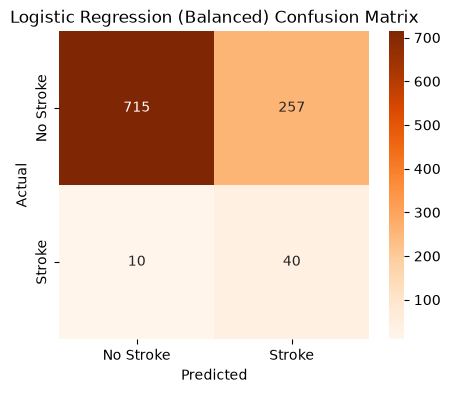

In [14]:
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

print("Logistic Regression (Balanced) Report")
print(classification_report(y_test, lr_preds))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, lr_preds), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
plt.title('Logistic Regression (Balanced) Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Final Models

Summary Comparison Table


,Model,Accuracy,Recall (Class 1),F1-Score (Class 1),True Positives (Detected),False Negatives (Missed)
0,KNN (Default Threshold 0.5),94.32,8.0,12.12,4,46
1,KNN (Tuned Threshold 0.15),84.83,24.0,13.41,12,38
2,Random Forest (Balanced),88.06,54.0,30.68,27,23
3,Logistic Regression (Balanced),73.87,80.0,23.05,40,10


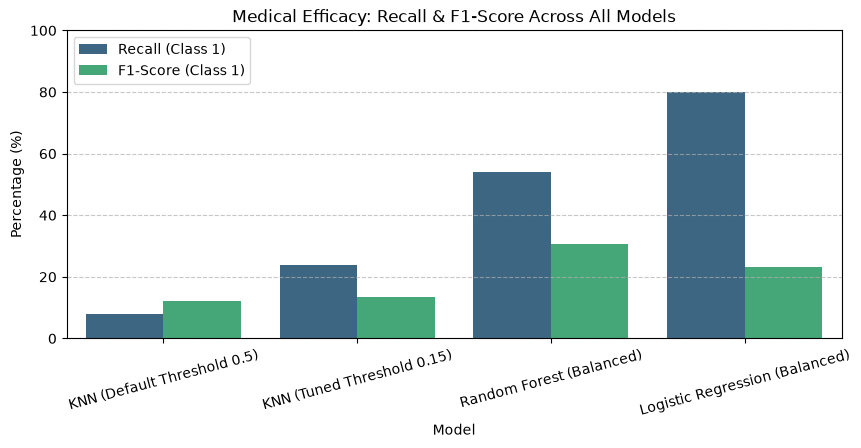

In [15]:
models = {
    'KNN (Default Threshold 0.5)': knn_baseline_preds,
    'KNN (Tuned Threshold 0.15)': knn_tuned_preds,
    'Random Forest (Balanced)': rf_preds,
    'Logistic Regression (Balanced)': lr_preds
}

summary = []
for name, preds in models.items():
    cm = confusion_matrix(y_test, preds)
    summary.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, preds) * 100, 2),
        'Recall (Class 1)': round(recall_score(y_test, preds, pos_label=1) * 100, 2),
        'F1-Score (Class 1)': round(f1_score(y_test, preds, pos_label=1) * 100, 2),
        'True Positives (Detected)': cm[1, 1],
        'False Negatives (Missed)': cm[1, 0]
    })

comparison_df = pd.DataFrame(summary)
print("Summary Comparison Table")
display(comparison_df)

plt.figure(figsize=(10, 4))
comparison_melted = pd.melt(comparison_df, id_vars=['Model'], value_vars=['Recall (Class 1)', 'F1-Score (Class 1)'],
                            var_name='Metric', value_name='Percentage')
sns.barplot(data=comparison_melted, x='Model', y='Percentage', hue='Metric', palette='viridis')
plt.title('Medical Efficacy: Recall & F1-Score Across All Models')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=15)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.show()